# 1. Setup and Imports

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 2. The Abstract Problem Interface

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

# 3. The Node Class

In [3]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

# 4. Helper Functions

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

# 5. Implementing the Grid Search Problem

In [5]:

 MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}
class GridProblem(Problem):

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
          neighbour = (row + dr, col + dc)
          if self.in_bounds(neighbour) and self.is_free(neighbour):
            legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
      row, col = state
      dr, dc = MOVES[action]
      return (row + dr, col + dc)

    def action_cost(self, state: Tuple[int, int],action: str,
                    next_state: Tuple[int, int]) -> float:
                    return 1


***5.1 Self-Check for GridProblem***

In [6]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


# 6. Sample Drone Map

In [7]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

# 7. Visualisation Helper

In [8]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

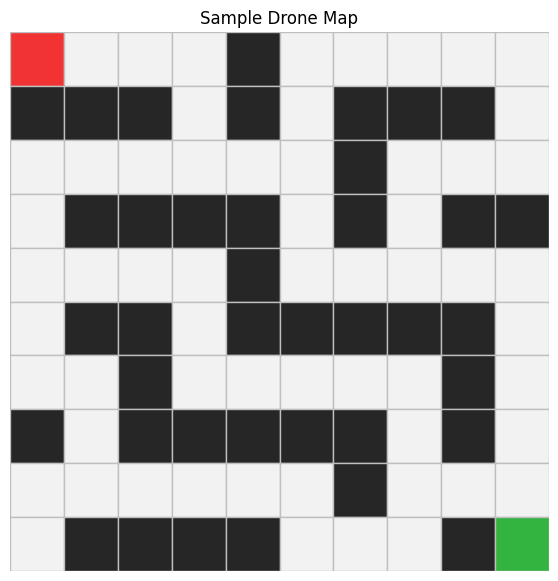

In [9]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

# 8. The Shared expand Method

In [10]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
      s = node.state
      for action in problem.actions(s):
        s_prime = problem.result(s, action)
        cost = node.path_cost + problem.action_cost(s, action, s_prime)
        yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

# 9. Breadth-First Search (BFS)

In [11]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(algorithm=algorithm, status="success", solution=node, nodes_expanded=0, max_frontier_size=1)

        nodes_expanded = 0
        max_frontier_size = 1
        reached = {node.state}
        frontier = deque([node])

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm=algorithm, status="success", solution=child,
                            nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size)
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm=algorithm, status="failure", solution=None,
                nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))

# 10. Depth-First Search (DFS)

In [12]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 0

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(algorithm, "success", node, nodes_expanded, max_frontier_size)

        frontier = [node]
        reached = {node.state}

        while frontier:
            max_frontier_size = max(max_frontier_size, len(frontier))
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm, "success", child, nodes_expanded, max_frontier_size, len(reached))
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))


# 11. Depth-Limited Search (DLS)

In [13]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"
        initial_node = Node(problem.initial_state())
        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }
        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )
        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(self, problem, node, limit, metrics, current_stack_size):
        if problem.is_goal(node.state):
            return node, "success"
        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue
            metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
            result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size + 1)

            if status == "success":
                return result, "success"
            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        return None, "failure"

# 12. Iterative Deepening Search (IDS)

In [14]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"
        total_nodes_expanded = 0
        overall_max_stack = 0
        iteration_log = []

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)
            total_nodes_expanded += result.nodes_expanded
            overall_max_stack = max(overall_max_stack, result.max_frontier_size)

            iteration_log.append({"limit": limit, "status": result.status})

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=overall_max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=overall_max_stack,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

# 13. Run the Algorithms on the Sample Map

In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


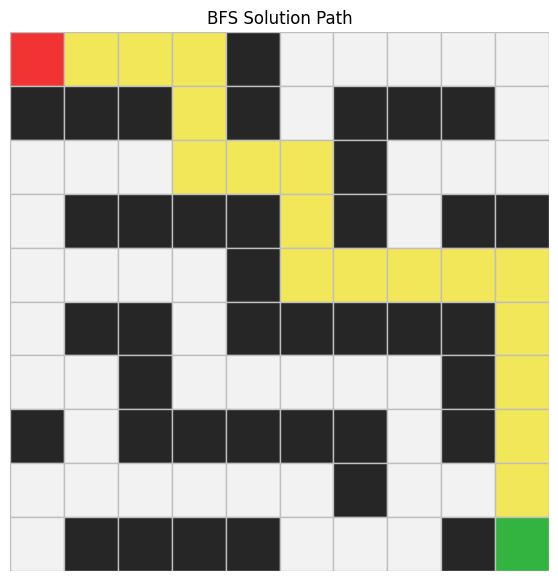

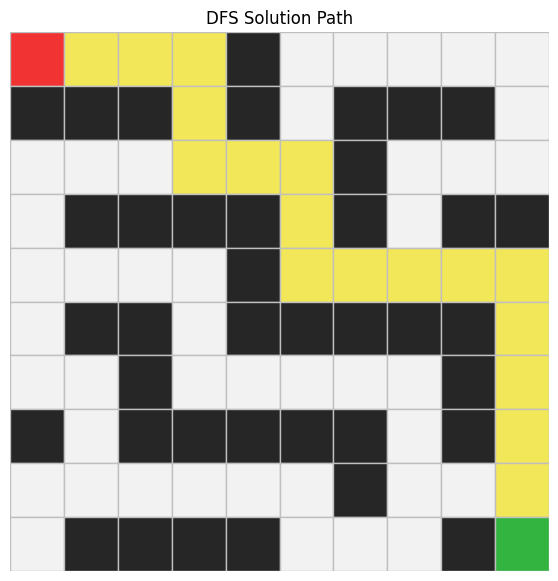

In [17]:


bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

# 14. Create Your Own Maps

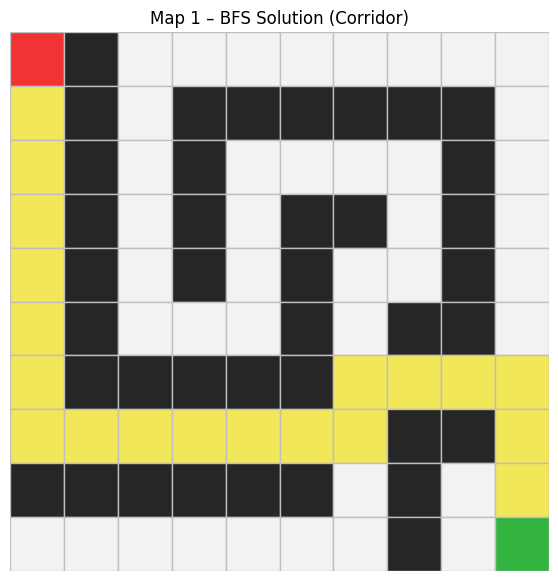

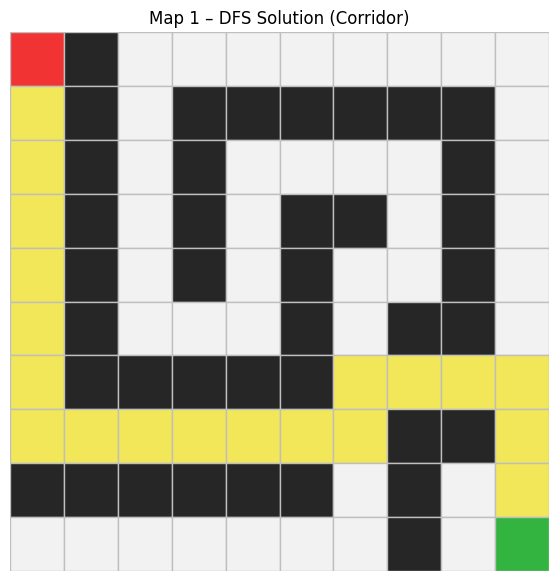

In [21]:
custom_grid_1 = [
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=25),
    ids.search(custom_problem_1, max_depth=40)]

show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[0].path, title="Map 1 – BFS Solution (Corridor)")
plot_path(custom_grid_1, custom_start_1, custom_goal_1,
          path=custom_results_1[1].path, title="Map 1 – DFS Solution (Corridor)")

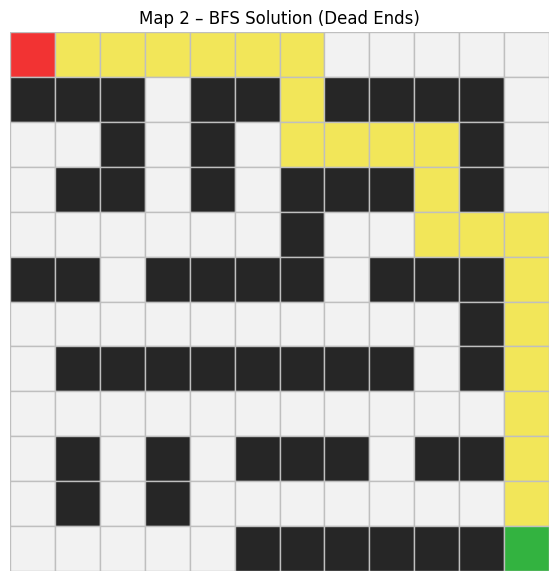

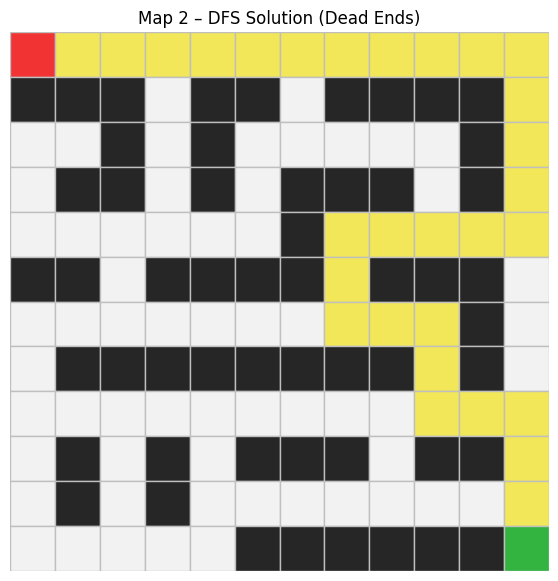

In [23]:
custom_grid_2 = [
   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0]
]

custom_start_2 = (0, 0)
custom_goal_2 = (11, 11)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=30),
    ids.search(custom_problem_2, max_depth=50),
]

show_results(custom_results_2)

plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[0].path, title="Map 2 – BFS Solution (Dead Ends)")
plot_path(custom_grid_2, custom_start_2, custom_goal_2,
          path=custom_results_2[1].path, title="Map 2 – DFS Solution (Dead Ends)")

# 15. Reflection Questions

***15.1 Problem Formulation***



1.   State is a tuple with a row and a column showing the position of a drone on a grid.

2.   An action is a move (UP, DOWN, LEFT or RIGHT) that the drone can make to transition from one state to another.

3.   Result function is used to compute and return the result state of the drone if it were to take an action from the current state.

4.   It is useful to separate the problem definition from the search algorithm because a good algorithm must be re-usable and independent; the same search algorithm used to solve this drone map problem can be used to solve any other search problem without changing the code.



***15.2 BFS***


1.  BFS uses a FIFO queue so that it explores nodes closer to the initial node before nodes that are farther away.

2.  BFS is able to find the shortest path because it explores nodes closer to the initial node first, so, the first path found is always the shortest.

3. Reached set keeps track of all states we have reached and helps in avoiding state repetition and infinite loops



***15.3 DFS***



1.   DFS uses LIFO stack because it always expands the most recently added node and explores that path before backtracking to explore other branches.

2.   No, DFS is not guaranteed to always find the shortest path since it always explores the recently added node, which is not always the shortest, and it will stop if it finds the goal.

3. BFS's frontier keeps all nodes at the current depth level. So in a very wide but not deep search, BFS will store more nodes since it goes level by level. But since DFS keeps track of a single path it is exploring, it will use less memory compared to BFS.

4. DFS can perform badly when the search space has long branches that do not lead to the goal. Since it explores one path before backtracking, it can waste a lot of time exploring branches that will not lead to the goal, and if that path is infinite, it may never terminate.



***15.4 DLS***



1.  If the depth of the shortest path to the goal is greater than the depth limit, the search will never reach the goal since every brach is cutoff before it reaches the goal.

2.   Cutoff means the depth of the path has reached the limit so the path can not be explored further. DLS doesn't know whether the path leads to the goal, only that it has reached its limit.

3.   DLS has depth limit and it stops exploring the path when it reaches the limit but DFS has no limit, so it keeps on exploring until it reaches the goal or hits the dead end.

4. DLS  needs a path cycle check so that it will not explore the path it has  already explored which might lead to time wastage and not reaching the goal even if the shortest path depth to reach the goal was less or equal to depth limit.



***15.5 IDS***



1.   IDS repeats DLS with increasing limits because starting from smallest limit and increasing it as search goes ensures that the first time the goal is found, it is found at the smallest possible depth  giving the shortest path. If a smaller limit doesn't find the goal, IDS increases it, rather than guessing one limit upfront which might be too small and miss the goal or large and waste space.

2.   If the goal is not found on a certain limit, DLS stops there and returns cutoff but IDS continues to increase it until it finds the goal.

3. IDS behaves like DLS nut with depth limit, so, it only stores the current path it is exploring while BFS stores every node at the current level which might take a lot of memory for wide search spaces.

4. IDS has redundacy cost because, on each increment of depth limit, it re-explores every path starting from the root, so shallow nodes get expanded many times.




*****15.6 Real-World Drone Context*****





1.Several real-world factors could make one route safer or more practical than another:

*   Weather: Rain or strong wind could damage the drone.
*   The route used: some routes like flying over water or fire are riskier incase the drone has to make emergency landing.
*   How long the drone will travel: a drone might run out of the power before the task is completed.




2.   BFS beacause when all moves cost the same, it gurantees to find the path with the fewest steps and it is done directly with no redudancy.

3. DLS because DLS has a depth limit, which limits how deep the drone is allowed to search.

4.Limitations of the grid model compared to real drone navugation:


*   The grid model is done in a static environment which is not the case for the real drone navigation
*    The model moves in only four directions but real world drone moves in different directions and angles.
*   Every move in the model costs exactly 1, but in real life, different moves have different costs
*   The grid is in 2D but real drones operate in 3D.


